<a href="https://colab.research.google.com/github/gustavovazquez/ML/blob/main/04_Multicolinealidad_Importancia_Variables_pvalues_completo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

@ Gustavo Vazquez - UCU

# Importancia de variables, p-values y multicolinealidad en regresión lineal

**Objetivo del notebook**

Este notebook tiene como objetivo ayudar a comprender cómo analizar la **importancia de las variables** en un modelo de regresión lineal múltiple, y qué problemas aparecen cuando los predictores están correlacionados entre sí.

En particular, vamos a estudiar:

- qué significa que una variable sea “importante”;
- cómo interpretar coeficientes de regresión;
- qué información aportan los **p-values**;
- por qué la correlación con la variable objetivo no alcanza;
- qué ocurre cuando hay correlación entre variables predictoras;
- qué es la **multicolinealidad**;
- cómo diagnosticarla mediante matriz de correlación y **VIF**;
- cómo afecta la estabilidad de los coeficientes;
- algunas estrategias prácticas para tratarla.

La idea central será:

> Una variable puede parecer importante según una medida y no según otra. Por eso, en regresión, la importancia de variables debe analizarse desde varias perspectivas.

## 1. ¿Qué significa que una variable sea importante?

En aprendizaje automático y estadística, la frase *“esta variable es importante”* puede tener distintos significados.

Por ejemplo, una variable puede ser importante porque:

- está fuertemente asociada con la salida `y`;
- tiene un coeficiente grande en una regresión;
- tiene un p-value pequeño;
- mejora mucho la capacidad predictiva del modelo;
- representa una variable relevante desde el punto de vista del dominio del problema.

Estas ideas están relacionadas, pero **no son equivalentes**.

| Enfoque | Qué mide | Pregunta que responde | Limitación |
|---|---|---|---|
| Correlación con `y` | Asociación bivariada | ¿Esta variable se relaciona con la salida? | Ignora las demás variables |
| Coeficiente de regresión | Efecto condicional | ¿Cómo cambia `y` si cambia esta variable, manteniendo las demás constantes? | Depende de escala y colinealidad |
| Coeficiente estandarizado | Efecto condicional comparable | ¿Qué variable tiene mayor efecto relativo dentro del modelo lineal? | Sigue siendo sensible a colinealidad |
| p-value | Evidencia estadística contra $H_0: \beta_j = 0$ | ¿Hay evidencia de que el coeficiente no sea cero? | No mide tamaño del efecto ni utilidad predictiva |
| Importancia por permutación | Pérdida de desempeño al alterar una variable | ¿Cuánto necesita el modelo esta variable para predecir? | Se complica si hay variables redundantes |
| VIF | Redundancia entre predictores | ¿Esta variable puede explicarse usando otras variables? | No mide relación directa con `y` |

En este notebook veremos por qué conviene combinar estas miradas.

## 2. Modelo de regresión lineal múltiple

En regresión lineal múltiple modelamos una variable objetivo $y$ usando varias variables predictoras:

$$
y = \beta_0 + \beta_1X_1 + \beta_2X_2 + \cdots + \beta_pX_p + \varepsilon
$$

Cada coeficiente $\beta_j$ se interpreta como un **efecto condicional**:

> cuánto cambia $y$ cuando aumenta $X_j$ en una unidad, manteniendo constantes las demás variables.

Esta aclaración es fundamental. En regresión múltiple, el coeficiente de una variable no mide simplemente la relación aislada entre esa variable y `y`. Mide su contribución una vez que el modelo ya tiene en cuenta las demás variables.

## 3. p-values en regresión lineal

En regresión lineal clásica, para cada coeficiente $\beta_j$ se suele plantear el contraste de hipótesis:

$$
H_0: \beta_j = 0
$$

frente a:

$$
H_1: \beta_j \neq 0
$$

El **p-value** asociado al coeficiente evalúa qué tan compatibles son los datos con la hipótesis nula $H_0$, bajo los supuestos del modelo.

Una interpretación práctica es:

- un p-value pequeño sugiere evidencia estadística de que el coeficiente es distinto de cero;
- un p-value grande no prueba que la variable sea inútil;
- el p-value no mide la magnitud del efecto;
- el p-value no mide directamente la importancia predictiva;
- el p-value puede cambiar mucho cuando hay multicolinealidad.

### Advertencia importante

Un p-value pequeño **no significa automáticamente** que una variable sea “muy importante”.

Un p-value responde una pregunta estadística específica:

> ¿Hay evidencia para rechazar que el coeficiente de esta variable sea cero, controlando por las demás variables del modelo?

Pero no responde directamente:

- cuánto mejora la predicción;
- si la variable es causal;
- si el efecto es grande o pequeño en términos prácticos;
- si otra variable contiene información redundante;
- si el modelo será estable ante pequeñas variaciones de los datos.

In [55]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

np.random.seed(42)

## 4. Dataset sintético

Vamos a construir un dataset sencillo con tres variables predictoras:

- `X1`: variable informativa;
- `X2`: variable casi duplicada de `X1`, por lo tanto muy correlacionada con ella;
- `X3`: variable independiente, con menor efecto sobre `y`.

La variable objetivo será generada como:

$$
y = 3X_1 + 1.5X_3 + \varepsilon
$$

Observación importante: `X2` no aparece directamente en la fórmula de generación de `y`. Sin embargo, como `X2` es casi una copia de `X1`, también estará muy correlacionada con `y`.

In [56]:
# Generación del dataset sintético
n = 300

X1 = np.random.normal(loc=0, scale=1, size=n)
X2 = 0.95 * X1 + np.random.normal(loc=0, scale=0.15, size=n)  # casi copia de X1
X3 = np.random.normal(loc=0, scale=1, size=n)

epsilon = np.random.normal(loc=0, scale=1.0, size=n)
y = 3 * X1 + 1.5 * X3 + epsilon

df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'y': y
})

df.head()

,X1,X2,X3,y
0,0.496714,0.347529,0.756989,2.994299
1,-0.138264,-0.215378,-0.922165,-2.191380
2,0.647689,0.727398,0.869606,3.276219
3,1.523030,1.538434,1.355638,7.880998
4,-0.234153,-0.225581,0.413435,0.108791


## 5. Primera mirada: correlación de cada variable con `y`

Una forma simple de estudiar la relación entre una variable predictora y la salida es calcular la correlación entre cada predictor e `y`.

Pero esta mirada es **bivariada**: analiza una variable por vez e ignora las demás.

Eso puede ser engañoso cuando dos predictores contienen información parecida.

In [57]:
# Correlación de cada predictor con la variable objetivo
corr_with_y = df[['X1', 'X2', 'X3', 'y']].corr(numeric_only=True)['y'].drop('y')

corr_with_y.sort_values(ascending=False)

,y
X1,0.855268
X2,0.840937
X3,0.396374


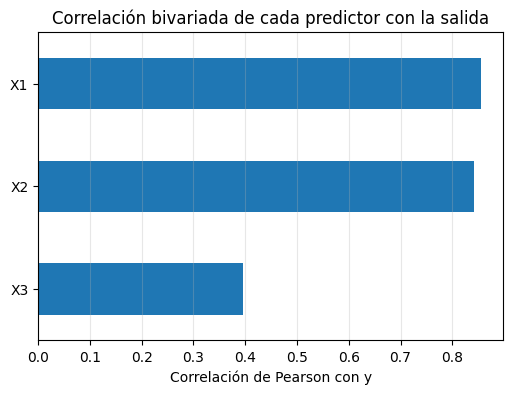

In [58]:
plt.figure(figsize=(6, 4))
corr_with_y.sort_values().plot(kind='barh')
plt.xlabel('Correlación de Pearson con y')
plt.title('Correlación bivariada de cada predictor con la salida')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Discusión

Es probable que `X1` y `X2` aparezcan ambas muy correlacionadas con `y`.

Sin embargo, eso no significa que ambas aporten información independiente al modelo. `X2` parece importante porque contiene casi la misma información que `X1`.

Esta es una primera señal de que la correlación con `y` no alcanza para definir importancia de variables.

## 6. Correlación entre predictores

Ahora analizamos la correlación entre las variables explicativas.

Cuando dos predictores están muy correlacionados entre sí, el modelo puede tener **dificultad para separar el efecto individual** de cada uno.

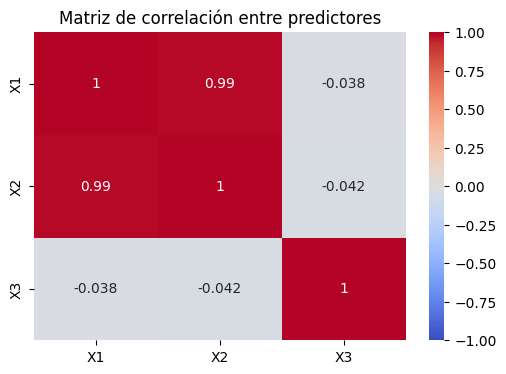

,X1,X2,X3
X1,1.000000,0.988182,-0.037822
X2,0.988182,1.000000,-0.042413
X3,-0.037822,-0.042413,1.000000


In [59]:
corr = df[['X1', 'X2', 'X3']].corr(numeric_only=True)

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Matriz de correlación entre predictores')
plt.show()

corr

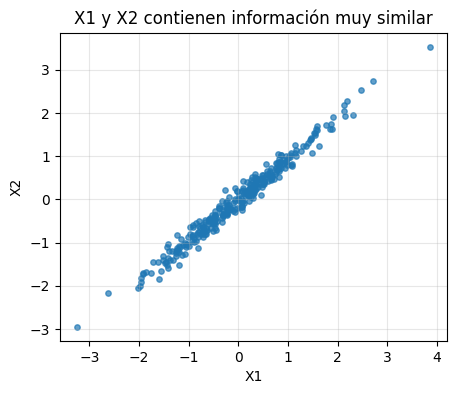

In [60]:
plt.figure(figsize=(5, 4))
plt.scatter(df['X1'], df['X2'], s=15, alpha=0.7)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('X1 y X2 contienen información muy similar')
plt.grid(alpha=0.3)
plt.show()

## 7. Modelo simple vs. modelo múltiple

Vamos a comparar dos modelos:

1. un modelo simple usando solo `X1`;
2. un modelo múltiple usando `X1`, `X2` y `X3`.

Esto permite observar cómo cambian los coeficientes y los p-values cuando agregamos variables correlacionadas.

In [61]:
# Modelo simple: y ~ X1
X_simple = sm.add_constant(df[['X1']])
model_simple = sm.OLS(df['y'], X_simple).fit()

print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     811.8
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           4.45e-87
Time:                        18:23:58   Log-Likelihood:                -600.91
No. Observations:                 300   AIC:                             1206.
Df Residuals:                     298   BIC:                             1213.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2217      0.104      2.134      0.0

In [62]:
# Modelo múltiple: y ~ X1 + X2 + X3
features = ['X1', 'X2', 'X3']
X_multi = sm.add_constant(df[features])
model_multi = sm.OLS(df['y'], X_multi).fit()

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     1072.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.32e-158
Time:                        18:23:58   Log-Likelihood:                -427.08
No. Observations:                 300   AIC:                             862.2
Df Residuals:                     296   BIC:                             877.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0984      0.059      1.679      0.0

### Interpretación

En el modelo simple, `X1` suele aparecer como claramente significativa porque está asociada con `y`.

En el modelo múltiple, el coeficiente de cada variable debe interpretarse **controlando por las demás**.

Como `X1` y `X2` contienen información muy parecida, el modelo tiene dificultad para decidir cuánto efecto asignar a cada una.

Por eso pueden ocurrir varios fenómenos:

- los errores estándar de los coeficientes aumentan;
- los p-values pueden aumentar;
- un coeficiente puede cambiar de magnitud;
- un coeficiente puede incluso cambiar de signo;
- el modelo puede seguir prediciendo bien, aunque los coeficientes individuales sean inestables.

## 8. Tabla combinada de coeficientes y p-values

Construimos una tabla más compacta con los coeficientes, errores estándar, estadísticos t y p-values del modelo múltiple.

In [63]:
coef_table = pd.DataFrame({
    'coeficiente': model_multi.params,
    'error_std': model_multi.bse,
    'p_value': model_multi.pvalues
})

coef_table

,coeficiente,error_std,p_value
const,0.098380,0.058606,9.427401e-02
X1,3.375279,0.387872,2.312902e-16
X2,-0.323680,0.406073,4.260339e-01
X3,1.491798,0.058762,2.763030e-76


### Cómo leer esta tabla

- `coeficiente`: estimación del efecto condicional.
- `error_std`: incertidumbre asociada a la estimación del coeficiente.
- `t_value`: relación entre coeficiente y error estándar.
- `p_value`: evidencia contra $H_0: \beta_j = 0$.

Cuando hay multicolinealidad, los errores estándar pueden aumentar. Eso puede producir p-values grandes incluso para variables que están relacionadas con la salida.

## 9. Coeficientes estandarizados

Los coeficientes originales dependen de la escala de las variables. Si una variable está medida en metros y otra en milímetros, sus coeficientes no son directamente comparables.

Para comparar efectos relativos, podemos estandarizar las variables predictoras.

La estandarización transforma cada predictor para que tenga media 0 y desvío estándar 1.

Después de estandarizar, los coeficientes indican cuánto cambia `y` cuando el predictor aumenta una desviación estándar.

In [64]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

lr_scaled = LinearRegression()
lr_scaled.fit(X_scaled, df['y'])

standardized_coefs = pd.Series(lr_scaled.coef_, index=features, name='coef_estandarizado')
standardized_coefs.sort_values(key=np.abs, ascending=False)

,coef_estandarizado
X1,3.316387
X3,1.484359
X2,-0.303833


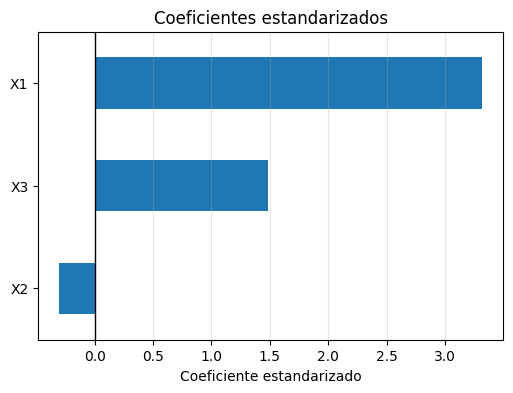

In [65]:
plt.figure(figsize=(6, 4))
standardized_coefs.sort_values().plot(kind='barh')
plt.xlabel('Coeficiente estandarizado')
plt.title('Coeficientes estandarizados')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', alpha=0.3)
plt.show()

### Advertencia

Los coeficientes estandarizados ayudan a comparar variables en distintas escalas, pero **no resuelven** el problema de multicolinealidad.

Si dos variables son redundantes, sus coeficientes pueden seguir siendo inestables.

## 10. Importancia por permutación

La importancia por permutación mide cuánto empeora el desempeño del modelo cuando se rompe la relación entre una variable y la salida.

El procedimiento es:

1. ajustar el modelo normalmente;
2. medir su desempeño;
3. mezclar aleatoriamente los valores de una variable;
4. volver a medir el desempeño;
5. si el desempeño cae mucho, esa variable era importante para predecir.

Esta es una medida de importancia **predictiva**, no necesariamente estadística ni causal.

In [66]:
X = df[features]
y = df['y']

lr = LinearRegression()
lr.fit(X, y)

base_r2 = r2_score(y, lr.predict(X))
base_r2

0.9157295705920931

In [67]:
perm = permutation_importance(
    lr,
    X,
    y,
    n_repeats=50,
    random_state=42,
    scoring='r2'
)

perm_table = pd.DataFrame({
    'variable': features,
    'perm_importance_mean': perm.importances_mean,
    'perm_importance_std': perm.importances_std
}).sort_values('perm_importance_mean', ascending=False)

perm_table

,variable,perm_importance_mean,perm_importance_std
0,X1,1.841430,0.117362
2,X3,0.368247,0.025579
1,X2,0.016043,0.003745


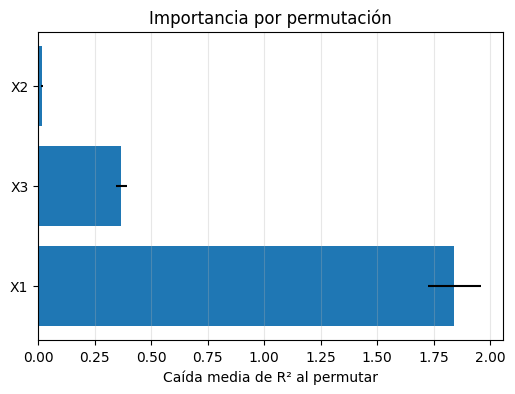

In [68]:
plt.figure(figsize=(6, 4))
plt.barh(perm_table['variable'], perm_table['perm_importance_mean'], xerr=perm_table['perm_importance_std'])
plt.xlabel('Caída media de R² al permutar')
plt.title('Importancia por permutación')
plt.grid(axis='x', alpha=0.3)
plt.show()

### Interpretación

La importancia por permutación puede ser muy útil, pero también tiene una limitación importante cuando hay variables correlacionadas.

Si dos variables contienen información redundante, al permutar una de ellas el modelo todavía puede usar la otra. Por eso, la importancia individual de cada una puede parecer menor de lo esperado.

En otras palabras:

> cuando hay variables redundantes, la importancia predictiva puede repartirse entre ellas.

## 11. Tabla integrada de importancia de variables

Ahora juntamos varias perspectivas en una sola tabla.

In [69]:
importance_table = pd.DataFrame({
    'variable': features,
    'corr_con_y': corr_with_y[features].values,
    'coeficiente': lr.coef_,
    'coef_estandarizado': standardized_coefs[features].values,
    'p_value': model_multi.pvalues[features].values,
    'perm_importance_mean': perm.importances_mean,
    'perm_importance_std': perm.importances_std
})

importance_table.sort_values('perm_importance_mean', ascending=False)

,variable,corr_con_y,coeficiente,coef_estandarizado,p_value,perm_importance_mean,perm_importance_std
0,X1,0.855268,3.375279,3.316387,2.312902e-16,1.841430,0.117362
2,X3,0.396374,1.491798,1.484359,2.763030e-76,0.368247,0.025579
1,X2,0.840937,-0.323680,-0.303833,4.260339e-01,0.016043,0.003745


### Mensaje didáctico

No hay una única columna que responda de manera universal cuál variable es más importante.

Cada columna responde una pregunta distinta:

- `corr_con_y`: relación aislada con la salida;
- `coeficiente`: efecto condicional dentro del modelo;
- `coef_estandarizado`: efecto condicional comparable en escala;
- `p_value`: evidencia estadística sobre si el coeficiente podría ser distinto de cero;
- `perm_importance_mean`: impacto predictivo al destruir la información de esa variable.

Cuando las variables están correlacionadas, estas medidas pueden no coincidir.

## 12. ¿Qué es multicolinealidad?

La **multicolinealidad** ocurre cuando una variable predictora puede explicarse, total o parcialmente, como combinación de otras variables predictoras.

En términos simples:

> hay multicolinealidad cuando varias variables explicativas contienen información redundante.

Esto no necesariamente impide predecir bien, pero puede afectar la interpretación del modelo.

### Consecuencias frecuentes

- Coeficientes inestables.
- Errores estándar grandes.
- p-values poco confiables o difíciles de interpretar.
- Cambios de signo en los coeficientes.
- Dificultad para determinar qué variable es realmente responsable del efecto.
- Sensibilidad a pequeñas variaciones de los datos.

## 13. VIF: Factor de Inflación de la Varianza

Una herramienta común para diagnosticar multicolinealidad es el **VIF** (*Variance Inflation Factor*).

Para una variable $X_j$, el VIF se define como:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

Donde $R_j^2$ es el coeficiente de determinación obtenido al predecir $X_j$ usando las demás variables explicativas.

Interpretación general:

- VIF cercano a 1: baja colinealidad;
- VIF entre 5 y 10: posible problema;
- VIF mayor que 10: multicolinealidad fuerte.

Estos umbrales son orientativos, no reglas absolutas.

In [70]:
def compute_vif(X_df):
    X_const = sm.add_constant(X_df)
    vif_values = []
    for i, col in enumerate(X_const.columns):
        if col == 'const':
            continue
        vif_values.append({
            'variable': col,
            'VIF': variance_inflation_factor(X_const.values, i)
        })
    return pd.DataFrame(vif_values)

vif_table = compute_vif(df[features])
vif_table

,variable,VIF
0,X1,42.591680
1,X2,42.607396
2,X3,1.002517


### Interpretación

Si `X1` y `X2` tienen VIF muy altos, significa que cada una puede ser explicada en gran medida por la otra.

Eso indica redundancia entre predictores.

El modelo puede seguir teniendo buen desempeño, pero los coeficientes individuales de `X1` y `X2` pueden no ser confiables para interpretación.

## 14. Inestabilidad de coeficientes mediante bootstrap

Una forma visual y práctica de mostrar la inestabilidad consiste en repetir el ajuste muchas veces sobre muestras bootstrap.

El bootstrap consiste en generar nuevas muestras tomando observaciones del dataset original con reemplazo.

Si los coeficientes cambian mucho entre muestras parecidas, eso indica que la interpretación individual de esos coeficientes es frágil.

In [71]:
B = 500
boot_coefs = []

for b in range(B):
    sample_idx = np.random.choice(df.index, size=len(df), replace=True)
    sample = df.loc[sample_idx]

    X_b = sample[features]
    y_b = sample['y']

    model_b = LinearRegression()
    model_b.fit(X_b, y_b)
    boot_coefs.append(model_b.coef_)

boot_coefs = pd.DataFrame(boot_coefs, columns=features)
boot_coefs.head()

,X1,X2,X3
0,3.599902,-0.578034,1.438555
1,3.718196,-0.659353,1.440613
2,2.825079,0.338975,1.545276
3,3.646382,-0.629617,1.468549
4,3.314623,-0.277179,1.424882


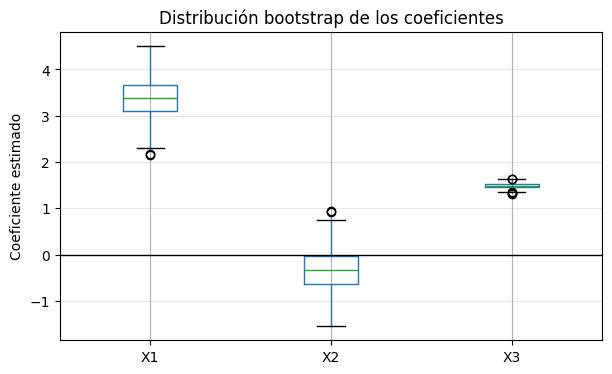

In [72]:
plt.figure(figsize=(7, 4))
boot_coefs.boxplot()
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Coeficiente estimado')
plt.title('Distribución bootstrap de los coeficientes')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [73]:
boot_summary = boot_coefs.agg(['mean', 'std', 'min', 'max']).T
boot_summary

,mean,std,min,max
X1,3.384134,0.401578,2.152628,4.501649
X2,-0.334690,0.422777,-1.548427,0.933362
X3,1.491460,0.054823,1.307920,1.636483


### Interpretación

Si los coeficientes de `X1` y `X2` varían mucho entre muestras, eso muestra que el modelo no puede asignar con estabilidad el efecto a una u otra variable.

Esto es típico cuando hay multicolinealidad.

La predicción puede ser buena, pero la interpretación individual de los coeficientes puede ser débil.

## 15. Comparación: modelo con variables redundantes vs. modelo reducido

Una estrategia simple cuando dos variables son casi duplicadas es eliminar una de ellas.

Vamos a comparar:

- modelo completo: `X1`, `X2`, `X3`;
- modelo reducido: `X1`, `X3`.

In [74]:
def fit_and_report_statsmodels(data, predictors, target='y'):
    X_sm = sm.add_constant(data[predictors])
    model = sm.OLS(data[target], X_sm).fit()
    table = pd.DataFrame({
        'coeficiente': model.params,
        'error_std': model.bse,
        't_value': model.tvalues,
        'p_value': model.pvalues
    })
    return model, table

model_full, table_full = fit_and_report_statsmodels(df, ['X1', 'X2', 'X3'])
model_reduced, table_reduced = fit_and_report_statsmodels(df, ['X1', 'X3'])

print('R2 modelo completo:', model_full.rsquared)
print('R2 modelo reducido:', model_reduced.rsquared)

R2 modelo completo: 0.9157295705920931
R2 modelo reducido: 0.9155486844260629


In [75]:
print('Modelo completo')
display(table_full)

print('Modelo reducido')
display(table_reduced)

Modelo completo


,coeficiente,error_std,t_value,p_value
const,0.098380,0.058606,1.678658,9.427401e-02
X1,3.375279,0.387872,8.702041,2.312902e-16
X2,-0.323680,0.406073,-0.797097,4.260339e-01
X3,1.491798,0.058762,25.387009,2.763030e-76


Modelo reducido


,coeficiente,error_std,t_value,p_value
const,0.099308,0.058559,1.695864,9.095954e-02
X1,3.069764,0.059439,51.645763,2.052030e-150
X3,1.493338,0.058694,25.442600,1.397209e-76


In [76]:
print('VIF modelo completo')
display(compute_vif(df[['X1', 'X2', 'X3']]))

print('VIF modelo reducido')
display(compute_vif(df[['X1', 'X3']]))

VIF modelo completo


,variable,VIF
0,X1,42.591680
1,X2,42.607396
2,X3,1.002517


VIF modelo reducido


,variable,VIF
0,X1,1.001433
1,X3,1.001433


### Discusión

Al eliminar `X2`, el modelo pierde muy poca capacidad explicativa porque `X2` era casi redundante con `X1`.

Pero la interpretación puede mejorar:

- los VIF bajan;
- los errores estándar pueden reducirse;
- los p-values pueden volverse más claros;
- los coeficientes pueden ser más estables.

Esto muestra que agregar más variables no siempre mejora la interpretabilidad del modelo.

## 16. Estrategia alternativa: combinar variables correlacionadas

Otra estrategia consiste en combinar variables redundantes en una nueva variable sintética.

Por ejemplo, si `X1` y `X2` miden casi lo mismo, podemos usar su promedio:

$$
X_{12} = \frac{X_1 + X_2}{2}
$$

Esto no siempre es la mejor opción, pero sirve como ejemplo de reducción de redundancia.

In [77]:
df_combined = df.copy()
df_combined['X12_promedio'] = (df_combined['X1'] + df_combined['X2']) / 2

model_combined, table_combined = fit_and_report_statsmodels(df_combined, ['X12_promedio', 'X3'])

print('R2 modelo combinado:', model_combined.rsquared)
display(table_combined)
display(compute_vif(df_combined[['X12_promedio', 'X3']]))

R2 modelo combinado: 0.9095132218212044


,coeficiente,error_std,t_value,p_value
const,0.103752,0.060616,1.711635,8.800784e-02
X12_promedio,3.136902,0.063123,49.694740,5.831007e-146
X3,1.500022,0.060761,24.687194,6.150718e-74


,variable,VIF
0,X12_promedio,1.001617
1,X3,1.001617


### Discusión

La variable combinada representa la información compartida entre `X1` y `X2`.

Esto puede mejorar la estabilidad interpretativa, aunque se pierde la posibilidad de diferenciar el efecto individual de `X1` y `X2`.

En problemas reales, esta decisión debe apoyarse en conocimiento del dominio.

## 17. Regularización: Ridge Regression

Cuando el objetivo principal es predecir, una alternativa práctica es usar modelos regularizados.

La regresión Ridge agrega una penalización a los coeficientes grandes:

$$
\text{Error Ridge} = \text{MSE} + \alpha \sum_{j=1}^{p} \beta_j^2
$$

Ridge no elimina variables, pero tiende a estabilizar los coeficientes cuando hay predictores correlacionados.

Es importante aclarar:

> Ridge ayuda a mejorar la estabilidad predictiva, pero los coeficientes siguen requiriendo cuidado al interpretarse.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['y'], test_size=0.3, random_state=42
)

ols_pipe = make_pipeline(StandardScaler(), LinearRegression())
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=10.0))

ols_pipe.fit(X_train, y_train)
ridge_pipe.fit(X_train, y_train)

ols_pred = ols_pipe.predict(X_test)
ridge_pred = ridge_pipe.predict(X_test)

comparison = pd.DataFrame({
    'modelo': ['OLS', 'Ridge'],
    'R2_test': [r2_score(y_test, ols_pred), r2_score(y_test, ridge_pred)],
    'RMSE_test': [
        np.sqrt(mean_squared_error(y_test, ols_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred))
    ]
})

comparison

,modelo,R2_test,RMSE_test
0,OLS,0.897037,0.957394
1,Ridge,0.894911,0.967230


## 18. Ejemplo de multicolinealidad sin correlaciones par a par extremas

La matriz de correlación puede detectar colinealidad entre pares de variables, pero no siempre detecta problemas más generales.

Puede ocurrir que una variable sea combinación de varias otras, aunque no tenga correlación extremadamente alta con ninguna de ellas por separado.

Vamos a crear un ejemplo:

$$
X_4 = X_1 + X_2 + X_3 + \eta
$$

En este caso, `X4` está muy relacionada con el conjunto formado por `X1`, `X2` y `X3`.

In [81]:
np.random.seed(123)
n2 = 400

A = np.random.normal(size=n2)
B = np.random.normal(size=n2)
C = np.random.normal(size=n2)
D = A + B + C + np.random.normal(scale=0.05, size=n2)

y2 = 2*A - 1.5*B + 0.5*C + np.random.normal(scale=1.0, size=n2)

df2 = pd.DataFrame({'A': A, 'B': B, 'C': C, 'D': D, 'y': y2})

df2.head()

,A,B,C,D,y
0,-1.085631,1.534090,-0.121167,0.382878,-5.081398
1,0.997345,-0.529914,-2.008585,-1.532106,2.850652
2,0.282978,-0.490972,-0.920647,-1.062000,0.318170
3,-1.506295,-1.309165,0.168234,-2.597779,-0.418736
4,-0.578600,-0.008660,-1.319892,-1.938001,-2.370036


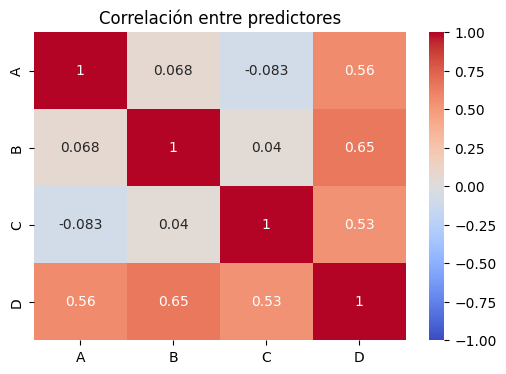

,variable,VIF
0,A,483.097782
1,B,519.150855
2,C,462.326195
3,D,1491.778428


In [82]:
plt.figure(figsize=(6, 4))
sns.heatmap(df2[['A', 'B', 'C', 'D']].corr(), annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlación entre predictores')
plt.show()

compute_vif(df2[['A', 'B', 'C', 'D']])

### Interpretación

Aunque algunas correlaciones par a par no parezcan extremas, el VIF puede mostrar un problema fuerte.

Esto ocurre porque el VIF no pregunta solamente si dos variables están correlacionadas entre sí. Pregunta algo más general:

> ¿puede esta variable ser explicada usando una combinación de las demás variables?

Por eso, el VIF puede detectar multicolinealidad que la matriz de correlación no muestra claramente.

## 19. Guía práctica para analizar importancia de variables

Una posible secuencia de análisis es la siguiente:

### Paso 1: mirar correlaciones con la salida

Sirve como primera exploración.

Pregunta:

> ¿Qué variables parecen asociadas con `y` de manera individual?

### Paso 2: mirar correlaciones entre predictores

Pregunta:

> ¿Hay variables que contienen información parecida?

### Paso 3: ajustar un modelo lineal múltiple

Analizar:

- coeficientes;
- signos;
- errores estándar;
- p-values;
- $R^2$.

### Paso 4: calcular VIF

Pregunta:

> ¿Hay variables que pueden explicarse mediante las demás?

### Paso 5: analizar estabilidad

Usar bootstrap o validación cruzada para observar si los coeficientes son estables.

### Paso 6: comparar importancia predictiva

Usar importancia por permutación u otras técnicas.

### Paso 7: decidir una estrategia

Según el objetivo:

- si el objetivo es interpretar, puede convenir eliminar o combinar variables redundantes;
- si el objetivo es predecir, puede convenir usar regularización;
- si el objetivo es causal, se requiere un análisis más profundo y conocimiento del dominio.

## 20. Cierre conceptual

La multicolinealidad no necesariamente destruye la capacidad predictiva del modelo, pero sí puede dificultar la interpretación de los coeficientes.

La idea central del notebook es:

> cuando varias variables predictoras están correlacionadas, el modelo puede predecir bien, pero puede volverse difícil determinar qué variable es responsable de la predicción.

Por eso, para hablar de importancia de variables conviene distinguir:

| Concepto | Pregunta principal |
|---|---|
| Correlación con `y` | ¿La variable está asociada individualmente con la salida? |
| Coeficiente | ¿Cuál es el efecto condicional dentro del modelo? |
| p-value | ¿Hay evidencia estadística de que el coeficiente no sea cero? |
| Coeficiente estandarizado | ¿Qué efecto relativo tiene la variable en escala comparable? |
| Importancia por permutación | ¿Cuánto empeora la predicción si destruyo esta variable? |
| VIF | ¿La variable es redundante con otras variables predictoras? |

Conclusión práctica:

> No conviene decidir la importancia de una variable usando una sola métrica. Es mejor combinar evidencia estadística, desempeño predictivo, análisis de correlación entre predictores y conocimiento del dominio.

## 21. Actividades sugeridas para estudiantes

1. Identificar cuál variable parece más importante mirando solo la correlación con `y`.
2. Comparar esa conclusión con los coeficientes del modelo múltiple.
3. Analizar qué ocurre con los p-values cuando se incluyen `X1` y `X2` juntas.
4. Calcular VIF e identificar variables problemáticas.
5. Eliminar `X2` y comparar coeficientes, p-values, VIF y $R^2$.
6. Crear una nueva variable combinada entre `X1` y `X2` y evaluar el resultado.
7. Comparar OLS y Ridge en términos de estabilidad de coeficientes.
8. Explicar por qué una variable puede ser importante para predecir, pero no tener un p-value pequeño.
9. Explicar por qué una variable puede tener alta correlación con `y`, pero bajo aporte adicional en regresión múltiple.
10. Buscar un ejemplo real donde varias variables midan aspectos similares de un mismo fenómeno.